# Client test

In [1]:
from core.qiskit_builder import build_circuit
from simulation.qiskit_engine import run_statevector_simulation, run_shot_simulator
import numpy as np

In [2]:

# GHZ 4
instructions = [
    
    #{"name": "X", "qubits": [0]},
    #{"name": "X", "qubits": [1]},
    #{"name": "X", "qubits": [2]},
    #{"name": "X", "qubits": [3]},
    
    {"name": "H", "qubits": [0]},
    {"name": "CX", "qubits": [0,1]},
    {"name": "CX", "qubits": [0,2]},
    {"name": "CX", "qubits": [0,3]},
]
qc = build_circuit(num_qubits=4,num_clbits=4, instructions=instructions)

In [3]:
# doesnt work with measure working
statevector = run_statevector_simulation(qc)
print("Resulting Statevector:", np.round(statevector, 3).real)
print()
print("Probabilities:")
result = np.array(statevector).real

for i in range(16):
    binary_label = bin(i)[2:].zfill(4)
    p = (result*result)[i]
    if p > 0.1:
        print(f"Index {i} ({binary_label}): {p:.2f}")

Resulting Statevector: [0.707 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.707]

Probabilities:
Index 0 (0000): 0.50
Index 15 (1111): 0.50


In [4]:
# Using measure
# GHZ 4
instructions = [
    
    #{"name": "X", "qubits": [0]},
    #{"name": "X", "qubits": [1]},
    #{"name": "X", "qubits": [2]},
    #{"name": "X", "qubits": [3]},
    
    {"name": "H", "qubits": [0]},
    {"name": "CX", "qubits": [0,1]},
    {"name": "CX", "qubits": [0,2]},
    {"name": "CX", "qubits": [0,3]},
    {"name": "MEASURE_ALL"}
]
qc = build_circuit(num_qubits=4,num_clbits=4, instructions=instructions)

In [ ]:
# Shots based model
shots = 1000000000
noise_model = 'depolarizing'
#noise_model = 'thermal_relaxation'
result = run_shot_simulator(qc, shots, noise_model)

counts = result.get_counts()

print(counts)

{'0000 1100': 10, '0000 1111': 488799, '0000 0001': 1200, '0000 0000': 491144, '0000 0010': 1226, '0000 1011': 3704, '0000 0011': 5, '0000 0111': 1242, '0000 0100': 3826, '0000 1101': 1266, '0000 0101': 17, '0000 1001': 2495, '0000 0110': 2457, '0000 1000': 1291, '0000 1110': 1309, '0000 1010': 9}


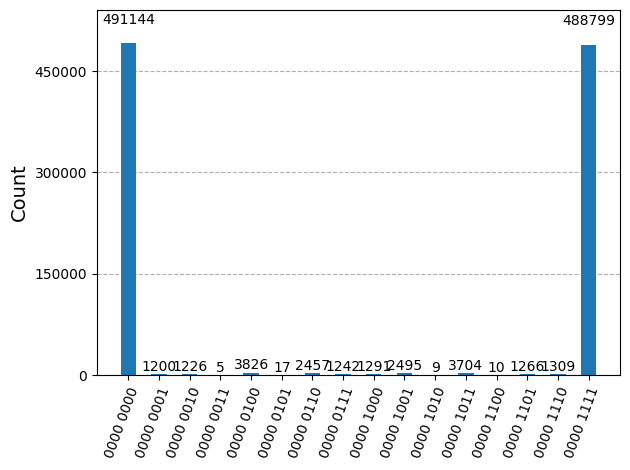

In [9]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

# AER test

In [7]:
from qiskit import transpile
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

sim = AerSimulator()
# --------------------------
# Simulating using estimator
#---------------------------
from qiskit_aer.primitives import EstimatorV2

psi1 = transpile(RealAmplitudes(num_qubits=2, reps=2), sim, optimization_level=0)
psi2 = transpile(RealAmplitudes(num_qubits=2, reps=3), sim, optimization_level=0)

H1 = SparsePauliOp.from_list([("II", 1), ("IZ", 2), ("XI", 3)])
H2 = SparsePauliOp.from_list([("IZ", 1)])
H3 = SparsePauliOp.from_list([("ZI", 1), ("ZZ", 1)])

theta1 = [0, 1, 1, 2, 3, 5]
theta2 = [0, 1, 1, 2, 3, 5, 8, 13]
theta3 = [1, 2, 3, 4, 5, 6]

estimator = EstimatorV2()

# calculate [ [<psi1(theta1)|H1|psi1(theta1)>,
#              <psi1(theta3)|H3|psi1(theta3)>],
#             [<psi2(theta2)|H2|psi2(theta2)>] ]
job = estimator.run(
    [
        (psi1, [H1, H3], [theta1, theta3]),
        (psi2, H2, theta2)
    ],
    precision=0.01
)
result = job.result()
print(f"expectation values : psi1 = {result[0].data.evs}, psi2 = {result[1].data.evs}")

# --------------------------
# Simulating using sampler
# --------------------------
from qiskit_aer.primitives import SamplerV2
from qiskit import QuantumCircuit

# create a Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# create two parameterized circuits
pqc = RealAmplitudes(num_qubits=2, reps=2)
pqc.measure_all()
pqc = transpile(pqc, sim, optimization_level=0)
pqc2 = RealAmplitudes(num_qubits=2, reps=3)
pqc2.measure_all()
pqc2 = transpile(pqc2, sim, optimization_level=0)

theta1 = [0, 1, 1, 2, 3, 5]
theta2 = [0, 1, 2, 3, 4, 5, 6, 7]

# initialization of the sampler
sampler = SamplerV2()

# collect 128 shots from the Bell circuit
job = sampler.run([bell], shots=128)
job_result = job.result()
print(f"counts for Bell circuit : {job_result[0].data.meas.get_counts()}")
 
# run a sampler job on the parameterized circuits
job2 = sampler.run([(pqc, theta1), (pqc2, theta2)])
job_result = job2.result()
print(f"counts for parameterized circuit : {job_result[0].data.meas.get_counts()}")


# run a sampler job on the parameterized circuits with noise model of the actual hardware
bell_t = transpile(bell, AerSimulator(basis_gates=["ecr", "id", "rz", "sx"]), optimization_level=0)
job3 = sampler.run([bell_t], shots=128)
job_result = job3.result()
print(f"counts for Bell circuit w/noise: {job_result[0].data.meas.get_counts()}")

/tmp/ipykernel_68361/2379230011.py:12: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  psi1 = transpile(RealAmplitudes(num_qubits=2, reps=2), sim, optimization_level=0)
/tmp/ipykernel_68361/2379230011.py:13: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  psi2 = transpile(RealAmplitudes(num_qubits=2, reps=3), sim, optimization_level=0)


expectation values : psi1 = [ 1.56323667 -1.08495952], psi2 = 0.17669144472776815
counts for Bell circuit : {'11': 72, '00': 56}
counts for parameterized circuit : {'11': 418, '01': 373, '00': 137, '10': 96}
counts for Bell circuit w/noise: {'11': 61, '00': 67}


/tmp/ipykernel_68361/2379230011.py:51: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  pqc = RealAmplitudes(num_qubits=2, reps=2)
/tmp/ipykernel_68361/2379230011.py:54: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  pqc2 = RealAmplitudes(num_qubits=2, reps=3)
